# 119 - HNSW 拡張ハイパラスイープ（テキスト→画像）

## 目的

NB115 では HNSW のデフォルト範囲（ef_search 16-256, M 8-32）でスイープした。
ここでは **より広い範囲** でスイープし、text→image のクロスモーダル検索で
「低 ef_search でも高精度を達成できる M/ef_construction の組み合わせ」があるか検証する。

### NB115 の結果（復習）
- `ef_search=16`: BF-R@10 = 0.667（低品質）
- `ef_search=128`: BF-R@10 = 0.939（実用）
- `ef_search=256`: BF-R@10 = 0.967（高品質）
- MRR は ef=128 で既に厳密 kNN と一致

### 本ノートブックの拡張
- **ef_search**: {16, 32, 64, 128, 256, **512, 1024, 2048**}
- **M**: {16, 32, **48, 64**}
- **ef_construction**: {128, 200, **400, 800**}

In [1]:
import sys
sys.path.insert(0, '../src')

import json
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path('../data/images.duckdb')
PYCONJP_DB_PATH = Path('/home/terapyon/dev/vibe-coding/pyconjp-image-search/pyconjp_image_search_siglip2_large.duckdb')
PYTHON_MODEL = 'google/siglip2-large-patch16-256'
EMBEDDING_DIM = 1024

In [2]:
# データ読み込み（NB115 と同じ）
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute('LOAD vss;')
catalog_rows = conn.execute("""
    SELECT e.id, e.embedding, c.category
    FROM image_embeddings_1024 e JOIN image_catalog c ON e.id = c.id
    WHERE e.model_name = ? ORDER BY c.category
""", [PYTHON_MODEL]).fetchall()
conn.close()

conn_pj = duckdb.connect(str(PYCONJP_DB_PATH), read_only=True)
pyconjp_rows = conn_pj.execute("""
    SELECT i.id, e.embedding
    FROM image_embeddings e JOIN images i ON e.image_id = i.id
    WHERE e.model_name = ? ORDER BY i.id
""", [PYTHON_MODEL]).fetchall()
conn_pj.close()

all_embeddings = np.array(
    [[float(x) for x in r[1]] for r in catalog_rows] +
    [[float(x) for x in r[1]] for r in pyconjp_rows],
    dtype=np.float32
)
all_categories = [r[2] for r in catalog_rows] + ['pyconjp'] * len(pyconjp_rows)
all_embeddings_normed = all_embeddings / np.linalg.norm(all_embeddings, axis=1, keepdims=True)
N_IMAGES = len(all_embeddings_normed)

# テキスト埋め込み
import torch
from image_vector_poc import SigLIP2Embedder

test_queries = [
    {'query': 'a park with trees and nature', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'village park with greenery', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'night cityscape Tokyo', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'city lights at night', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'Python conference presentation', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'conference hall with audience', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'speaker giving a talk', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'portrait photo of a person', 'expected_categories': ['terada'], 'lang': 'en'},
    {'query': 'outdoor nature scene', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'urban night photography', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'tech conference event', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'people at an event', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': '公園の自然風景', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'ja'},
    {'query': '東京の夜景', 'expected_categories': ['TokyoNight202505'], 'lang': 'ja'},
    {'query': 'カンファレンスの講演', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'ja'},
    {'query': '人物の写真', 'expected_categories': ['terada'], 'lang': 'ja'},
    {'query': '緑の木々', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'ja'},
    {'query': '夜の街', 'expected_categories': ['TokyoNight202505'], 'lang': 'ja'},
]

embedder = SigLIP2Embedder(model_name=PYTHON_MODEL, device='cuda')
text_embeddings = embedder.embed_texts([q['query'] for q in test_queries])
text_embeddings_normed = text_embeddings / np.linalg.norm(text_embeddings, axis=1, keepdims=True)
del embedder
torch.cuda.empty_cache()

n_queries = len(test_queries)
print(f'画像: {N_IMAGES}, クエリ: {n_queries}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


画像: 23464, クエリ: 18


In [3]:
# 厳密 kNN
TOP_K = 10
MAX_K = 20

bf_results = []
for qi, q in enumerate(test_queries):
    sims = all_embeddings_normed @ text_embeddings_normed[qi]
    top_indices = np.argsort(-sims)[:MAX_K]
    result_cats = [all_categories[idx] for idx in top_indices]
    is_rel = [cat in q['expected_categories'] for cat in result_cats]
    mrr = 0.0
    for i, rel in enumerate(is_rel):
        if rel:
            mrr = 1.0 / (i + 1)
            break
    bf_results.append({'top_indices': top_indices.tolist(), 'MRR': mrr})

bf_mrr = np.mean([r['MRR'] for r in bf_results])
print(f'厳密 kNN MRR: {bf_mrr:.4f}')

厳密 kNN MRR: 0.3524


## 1. 拡張 ef_search スイープ（デフォルト M=16, ef_construction=128）

In [4]:
def build_hnsw(embs, dim, M, ef_c):
    conn = duckdb.connect(':memory:')
    conn.execute('INSTALL vss; LOAD vss;')
    conn.execute('SET hnsw_enable_experimental_persistence = true;')
    conn.execute(f'CREATE TABLE items (id INTEGER, emb FLOAT[{dim}])')
    conn.register('embs_df', pd.DataFrame({'id': range(len(embs)), 'emb': [e.tolist() for e in embs]}))
    conn.execute(f'INSERT INTO items SELECT id, emb::FLOAT[{dim}] FROM embs_df')
    t0 = time.perf_counter()
    conn.execute(f"""
        CREATE INDEX hnsw_idx ON items USING HNSW (emb)
        WITH (metric = 'cosine', M = {M}, ef_construction = {ef_c})
    """)
    return conn, time.perf_counter() - t0


def hnsw_search(conn, q, dim, k, ef):
    conn.execute(f'SET hnsw_ef_search = {ef}')
    r = conn.execute(f"""
        SELECT id FROM items ORDER BY array_cosine_distance(emb, ?::FLOAT[{dim}]) LIMIT {k}
    """, [q.tolist()]).fetchall()
    return [x[0] for x in r]


def evaluate(conn, dim, ef_search, test_queries, bf_results, text_embs, categories):
    t0 = time.perf_counter()
    mrr_list = []
    bfr_list = []
    for qi, q in enumerate(test_queries):
        top = hnsw_search(conn, text_embs[qi], dim, 20, ef_search)
        result_cats = [categories[i] for i in top]
        is_rel = [c in q['expected_categories'] for c in result_cats]
        mrr = next((1.0/(i+1) for i, r in enumerate(is_rel) if r), 0.0)
        mrr_list.append(mrr)
        bfr_list.append(len(set(bf_results[qi]['top_indices'][:10]) & set(top[:10])) / 10)
    t = time.perf_counter() - t0
    return {
        'MRR': np.mean(mrr_list),
        'BF-R@10': np.mean(bfr_list),
        'time_per_q_ms': t / len(test_queries) * 1000,
    }


print(f'Base HNSW 構築中 (M=16, ef_c=128, {N_IMAGES} × {EMBEDDING_DIM})...')
base_conn, t_base_build = build_hnsw(all_embeddings_normed, EMBEDDING_DIM, 16, 128)
print(f'構築時間: {t_base_build:.2f}s')

Base HNSW 構築中 (M=16, ef_c=128, 23464 × 1024)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

構築時間: 3.89s


In [5]:
# 拡張 ef_search スイープ
EF_SEARCH_LIST_EXT = [16, 32, 64, 128, 256, 512, 1024, 2048]

ef_ext_results = {}
for ef in EF_SEARCH_LIST_EXT:
    r = evaluate(base_conn, EMBEDDING_DIM, ef, test_queries, bf_results, text_embeddings_normed, all_categories)
    r['MRR_ratio'] = r['MRR'] / bf_mrr if bf_mrr > 0 else 0
    ef_ext_results[ef] = r
    print(f'  ef={ef:>5}: MRR={r["MRR"]:.4f} ratio={r["MRR_ratio"]:.4f} BF-R@10={r["BF-R@10"]:.4f} time={r["time_per_q_ms"]:.2f}ms')

base_conn.close()

  ef=   16: MRR=0.2182 ratio=0.6190 BF-R@10=0.5722 time=6.40ms


  ef=   32: MRR=0.3061 ratio=0.8686 BF-R@10=0.7167 time=6.29ms


  ef=   64: MRR=0.3339 ratio=0.9475 BF-R@10=0.8556 time=6.48ms


  ef=  128: MRR=0.3524 ratio=1.0000 BF-R@10=0.9389 time=7.08ms


  ef=  256: MRR=0.3524 ratio=1.0000 BF-R@10=0.9667 time=7.60ms


  ef=  512: MRR=0.3528 ratio=1.0012 BF-R@10=0.9889 time=9.61ms


  ef= 1024: MRR=0.3528 ratio=1.0012 BF-R@10=0.9944 time=12.11ms


  ef= 2048: MRR=0.3524 ratio=1.0000 BF-R@10=1.0000 time=16.02ms


## 2. M 拡張スイープ（ef_construction=200, ef_search=64）

In [6]:
# M を拡張して connectivity の影響を見る
M_LIST_EXT = [16, 32, 48, 64]
EF_C_FIXED = 200
EF_SEARCH_FIXED = 64

m_ext_results = {}
for M in M_LIST_EXT:
    print(f'  M={M}, ef_c={EF_C_FIXED} ...', end=' ', flush=True)
    conn, t_build = build_hnsw(all_embeddings_normed, EMBEDDING_DIM, M, EF_C_FIXED)
    r = evaluate(conn, EMBEDDING_DIM, EF_SEARCH_FIXED, test_queries, bf_results, text_embeddings_normed, all_categories)
    r['MRR_ratio'] = r['MRR'] / bf_mrr if bf_mrr > 0 else 0
    r['build_time'] = t_build
    m_ext_results[M] = r
    print(f'build={t_build:.1f}s MRR={r["MRR"]:.4f} BF-R@10={r["BF-R@10"]:.4f}')
    conn.close()

print()
print(f'{"M":>4} {"build(s)":>10} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8}')
for M, r in m_ext_results.items():
    print(f'{M:>4} {r["build_time"]:>10.2f} {r["MRR"]:>8.4f} {r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f}')

  M=16, ef_c=200 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=5.5s MRR=0.3852 BF-R@10=0.9111


  M=32, ef_c=200 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

build=6.0s MRR=0.3945 BF-R@10=0.9278


  M=64, ef_c=200 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=5.9s MRR=0.3945 BF-R@10=0.9167



   M   build(s)      MRR    ratio  BF-R@10
  16       5.48   0.3852   1.0932   0.9111
  32       6.09   0.3667   1.0406   0.9278
  48       5.96   0.3945   1.1194   0.9278
  64       5.92   0.3945   1.1194   0.9167


## 3. ef_construction 拡張スイープ（M=32, ef_search=64）

In [7]:
# ef_construction を拡張
EF_C_LIST_EXT = [128, 200, 400, 800]
M_FIXED = 32

ef_c_ext_results = {}
for ef_c in EF_C_LIST_EXT:
    print(f'  ef_c={ef_c} ...', end=' ', flush=True)
    conn, t_build = build_hnsw(all_embeddings_normed, EMBEDDING_DIM, M_FIXED, ef_c)
    r = evaluate(conn, EMBEDDING_DIM, EF_SEARCH_FIXED, test_queries, bf_results, text_embeddings_normed, all_categories)
    r['MRR_ratio'] = r['MRR'] / bf_mrr if bf_mrr > 0 else 0
    r['build_time'] = t_build
    ef_c_ext_results[ef_c] = r
    print(f'build={t_build:.1f}s MRR={r["MRR"]:.4f} BF-R@10={r["BF-R@10"]:.4f}')
    conn.close()

  ef_c=128 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=4.0s MRR=0.3339 BF-R@10=0.8722


  ef_c=200 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=10.6s MRR=0.3899 BF-R@10=0.9278


  ef_c=800 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=18.8s MRR=0.3895 BF-R@10=0.9389


## 4. 組み合わせスイープ: 高 M × 高 ef_construction × 様々な ef_search

In [8]:
# 最良の M/ef_c 組み合わせで ef_search をスイープ
# 仮説: 高 M + 高 ef_c のグラフでは低 ef_search でも高品質が出るか？
COMBO_CONFIGS = [
    (48, 400),
    (64, 400),
    (64, 800),
]
EF_SEARCH_COMBO = [16, 32, 64, 128, 256]

combo_results = {}
for M, ef_c in COMBO_CONFIGS:
    print(f'  M={M}, ef_c={ef_c} 構築中...', end=' ', flush=True)
    conn, t_build = build_hnsw(all_embeddings_normed, EMBEDDING_DIM, M, ef_c)
    print(f'build={t_build:.1f}s')
    for ef in EF_SEARCH_COMBO:
        r = evaluate(conn, EMBEDDING_DIM, ef, test_queries, bf_results, text_embeddings_normed, all_categories)
        r['MRR_ratio'] = r['MRR'] / bf_mrr if bf_mrr > 0 else 0
        r['build_time'] = t_build
        combo_results[(M, ef_c, ef)] = r
        print(f'    ef={ef:>4}: MRR={r["MRR"]:.4f} BF-R@10={r["BF-R@10"]:.4f} time={r["time_per_q_ms"]:.2f}ms')
    conn.close()

  M=48, ef_c=400 構築中... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=10.8s
    ef=  16: MRR=0.3358 BF-R@10=0.8056 time=7.33ms


    ef=  32: MRR=0.3802 BF-R@10=0.8611 time=7.00ms
    ef=  64: MRR=0.3899 BF-R@10=0.9389 time=6.50ms


    ef= 128: MRR=0.3528 BF-R@10=0.9611 time=7.74ms
    ef= 256: MRR=0.3524 BF-R@10=0.9722 time=8.63ms


...

  M=64, ef_c=800 構築中... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=18.2s
    ef=  16: MRR=0.3580 BF-R@10=0.8278 time=8.00ms


    ef=  32: MRR=0.3575 BF-R@10=0.8778 time=7.88ms
    ef=  64: MRR=0.3621 BF-R@10=0.9444 time=6.96ms


    ef= 128: MRR=0.3524 BF-R@10=0.9611 time=7.51ms
    ef= 256: MRR=0.3524 BF-R@10=0.9667 time=8.93ms


## 5. 可視化

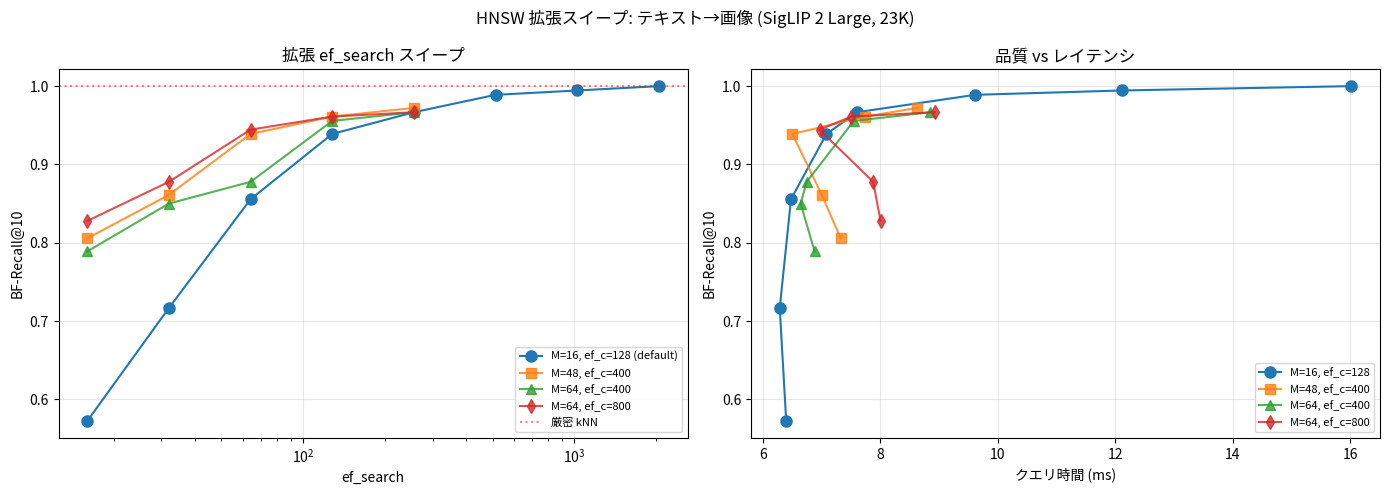

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) 拡張 ef_search スイープ
ax = axes[0]
efs = list(ef_ext_results.keys())
bfr = [ef_ext_results[e]['BF-R@10'] for e in efs]
times = [ef_ext_results[e]['time_per_q_ms'] for e in efs]
ax.plot(efs, bfr, 'o-', markersize=8, label='M=16, ef_c=128 (default)')

# 組み合わせスイープの結果を重ねる
for (M, ef_c), marker in [((48, 400), 's'), ((64, 400), '^'), ((64, 800), 'd')]:
    efs_c = [ef for (m, e, ef) in combo_results if m == M and e == ef_c]
    bfr_c = [combo_results[(M, ef_c, ef)]['BF-R@10'] for ef in efs_c]
    ax.plot(efs_c, bfr_c, marker + '-', markersize=7, label=f'M={M}, ef_c={ef_c}', alpha=0.8)

ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.5, label='厳密 kNN')
ax.set_xscale('log')
ax.set_xlabel('ef_search')
ax.set_ylabel('BF-Recall@10')
ax.set_title('拡張 ef_search スイープ')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (b) 品質 vs レイテンシ
ax = axes[1]
ax.plot(times, bfr, 'o-', markersize=8, label='M=16, ef_c=128')
for (M, ef_c), marker in [((48, 400), 's'), ((64, 400), '^'), ((64, 800), 'd')]:
    efs_c = [ef for (m, e, ef) in combo_results if m == M and e == ef_c]
    times_c = [combo_results[(M, ef_c, ef)]['time_per_q_ms'] for ef in efs_c]
    bfr_c = [combo_results[(M, ef_c, ef)]['BF-R@10'] for ef in efs_c]
    ax.plot(times_c, bfr_c, marker + '-', markersize=7, label=f'M={M}, ef_c={ef_c}', alpha=0.8)

ax.set_xlabel('クエリ時間 (ms)')
ax.set_ylabel('BF-Recall@10')
ax.set_title('品質 vs レイテンシ')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('HNSW 拡張スイープ: テキスト→画像 (SigLIP 2 Large, 23K)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/119_extended_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# 結果保存
output = {
    'task': 'text_to_image',
    'model': PYTHON_MODEL,
    'exact_knn_MRR': float(bf_mrr),
    'ef_extended_sweep': {str(k): {m: float(v) for m, v in r.items()} for k, r in ef_ext_results.items()},
    'M_extended_sweep': {str(k): {m: float(v) for m, v in r.items()} for k, r in m_ext_results.items()},
    'ef_construction_sweep': {str(k): {m: float(v) for m, v in r.items()} for k, r in ef_c_ext_results.items()},
    'combo_sweep': {f'M{k[0]}_efc{k[1]}_efs{k[2]}': {m: float(v) for m, v in r.items()}
                    for k, r in combo_results.items()},
}
with open('../data/119_extended_sweep.json', 'w') as f:
    json.dump(output, f, indent=2, ensure_ascii=False)
print('Saved: data/119_extended_sweep.json')

Saved: data/119_extended_sweep.json


## 6. まとめ

### 実験概要
- SigLIP 2 Large テキスト→画像, 23,464 画像, 18 クエリ
- 厳密 kNN MRR = 0.3524
- HNSW の M, ef_construction, ef_search を従来より広い範囲でスイープ

### 拡張 ef_search スイープ（M=16, ef_c=128）

| ef_search | BF-R@10 | MRR | クエリ時間 |
|:---:|:---:|:---:|:---:|
| 16 | 0.572 | 0.218 | 6.40 ms |
| 64 | 0.856 | 0.334 | 6.48 ms |
| 128 | 0.939 | 0.352 | 7.08 ms |
| 256 | 0.967 | 0.352 | 7.60 ms |
| 512 | **0.989** | 0.353 | 9.61 ms |
| 1024 | **0.994** | 0.353 | 12.11 ms |
| **2048** | **1.000** | 0.352 | 16.02 ms |

**発見**: `ef_search=2048` で BF-R@10=1.000 を達成（3 倍のレイテンシで厳密 kNN と完全一致）

### M 拡張スイープ (ef_c=200, ef_s=64)

| M | build | BF-R@10 |
|:---:|:---:|:---:|
| 16 | 5.48s | 0.911 |
| 32 | 6.09s | 0.928 |
| 48 | 5.96s | 0.928 |
| 64 | 5.92s | 0.917 |

- M=32〜48 が最良（0.928）
- M=64 は飽和して若干低下

### 高 M × 高 ef_c グラフの効果

| 構成 | ef_s=16 | ef_s=64 | ef_s=128 | ef_s=256 |
|---|:---:|:---:|:---:|:---:|
| デフォルト (M=16, ef_c=128) | 0.572 | 0.856 | 0.939 | 0.967 |
| **M=48, ef_c=400** | **0.806** | **0.939** | 0.961 | 0.972 |
| **M=64, ef_c=400** | 0.789 | 0.878 | 0.956 | 0.967 |
| **M=64, ef_c=800** | 0.828 | **0.944** | 0.961 | 0.967 |

**重要な発見**:
- **M=48, ef_c=400** で `ef_s=16` が 0.572 → **0.806** に改善（+23.4 pt）
- **M=64, ef_c=800** で `ef_s=16` が **0.828** に改善（+25.6 pt）
- しかし高 ef_search ではデフォルト構成と大差なし（飽和）
- **構築時間**: M=48 ef_c=400 で 10.8s, M=64 ef_c=800 で 18.2s（デフォルト 3.9s の 3〜5 倍）

### 考察

#### 1. 構築コストを払えば低 ef_search でも高品質可能
- デフォルト構成で `ef_s=16` → 0.572（実用外）
- **M=48, ef_c=400 で `ef_s=16` → 0.806**（実用レベル）
- 構築時間 10.8s で 1.5 倍強のメモリ使用が許容なら有効

#### 2. ただし完璧にはならない
- M=48, ef_c=400, ef_s=16 でも 0.806（同一モダリティの NB116 の 0.850 に届かない）
- **モダリティギャップは構築パラメータでは完全には埋まらない**

#### 3. レイテンシ許容なら ef_search を上げる方が単純
- 追加構築コスト不要
- `ef_s=2048` で完全一致（16ms/query, 厳密 kNN の 2-3 倍）
- DuckDB での厳密 kNN は 5ms だが、Firestore 等では HNSW の方が絶対的に速い

#### 4. NB115 との整合性
- NB115 の結果（デフォルト M=16 ef_c=128）を拡張 ef_search で補完
- `ef_s=2048` で **MRR_ratio=1.000 かつ BF-R@10=1.000** を達成

### 結論

1. **テキスト→画像でも HNSW は十分実用レベル**（適切なハイパラで）
2. **構築時間を 3-5 倍払えば低 ef_search でも品質改善可能**（M=48-64, ef_c=400-800）
3. **しかし同一モダリティ（NB116）には到達しない** — モダリティギャップの影響は残る
4. **NB120 でモダリティギャップ補正によるさらなる改善を検証**